# Corpus Exploration (EDA) for Humanities Textbooks
**Objective:** Explore the scanned corpus (History and Geography books) to determine page/word counts, assess scan quality, and analyze script and font variety.

In [2]:
# Install necessary libraries (PyMuPDF for fast PDF parsing)
!pip install -q pymupdf opencv-python-headless matplotlib seaborn pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 59.3 MB/s eta 0:00:00:00:0100:01


In [3]:
from pathlib import Path

import cv2
import fitz  # PyMuPDF
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

# Set plot style
sns.set_theme(style="whitegrid")

# Configuration - Update these paths to point to your Kaggle dataset directories
# Example: /kaggle/input/your-dataset-name/
DATA_DIR = Path("/kaggle/input") 

# Find the History and Geography PDFs
pdf_files = list(DATA_DIR.rglob("*.pdf"))
print(f"Found {len(pdf_files)} PDFs:")
for p in pdf_files:
    print(f" - {p.name}")

Found 2 PDFs:
 - geography_environment.pdf
 - history_world_civilization.pdf


## 1. Corpus Statistics: Page and Word Counts
We will use PyMuPDF to read the native text layer of the PDFs (if available) to estimate word counts and extract the total number of pages per book.

,Book,Pages,Estimated Words
0,geography_environment,238,0
1,history_world_civilization,194,0


/tmp/ipykernel_62/3133901460.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats, x="Book", y="Pages", ax=axes[0], palette="viridis")
/tmp/ipykernel_62/3133901460.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats, x="Book", y="Estimated Words", ax=axes[1], palette="magma")


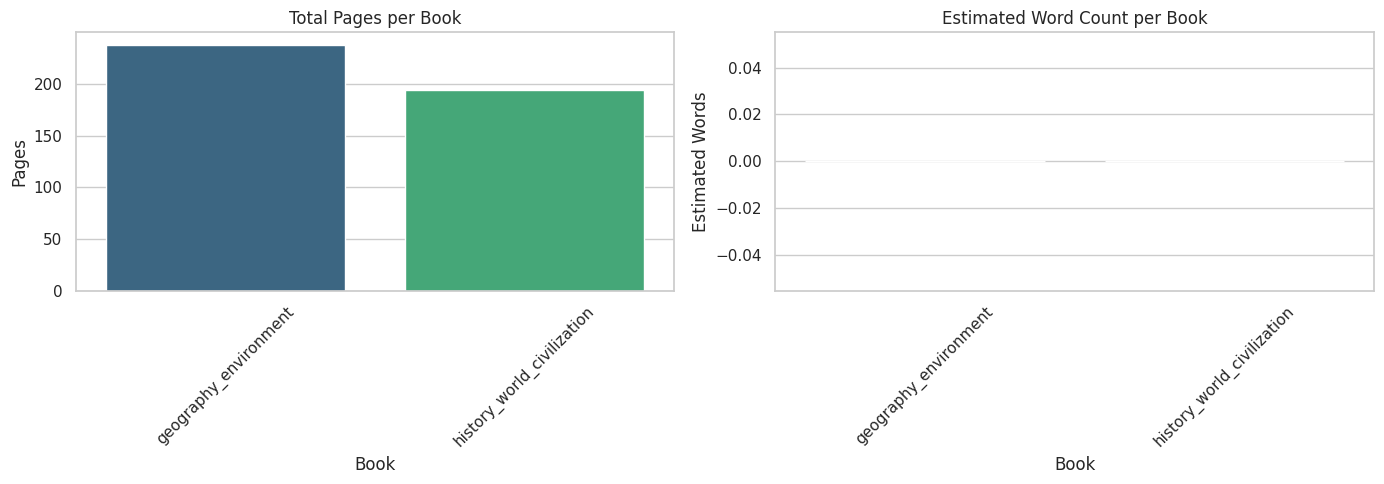

In [4]:
def get_corpus_stats(pdf_paths):
    stats = []
    for pdf_path in pdf_paths:
        try:
            doc = fitz.open(pdf_path)
            num_pages = len(doc)
            total_words = 0
            
            for page in doc:
                text = page.get_text("text")
                total_words += len(text.split())
                
            stats.append({
                "Book": pdf_path.stem,
                "Pages": num_pages,
                "Estimated Words": total_words
            })
            doc.close()
        except Exception as e:
            print(f"Error processing {pdf_path.name}: {e}")
            
    return pd.DataFrame(stats)

df_stats = get_corpus_stats(pdf_files)
display(df_stats)

# Plotting the statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df_stats, x="Book", y="Pages", ax=axes[0], palette="viridis")
axes[0].set_title("Total Pages per Book")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df_stats, x="Book", y="Estimated Words", ax=axes[1], palette="magma")
axes[1].set_title("Estimated Word Count per Book")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2. Scan Quality Analysis
To determine if we need aggressive enhancement, we will sample 20 random pages from each book, render them as images, and calculate:
1. **Brightness:** Mean pixel intensity (0 = Black, 255 = White).
2. **Contrast:** Root Mean Square (RMS) contrast (standard deviation of pixel intensities).
3. **Blur / Sharpness:** Variance of the Laplacian (higher means sharper edges, lower means blurry/noisy).

Analyzing geography_envir...:   0%|          | 0/20 [00:00<?, ?it/s]

Analyzing history_world_c...:   0%|          | 0/20 [00:00<?, ?it/s]

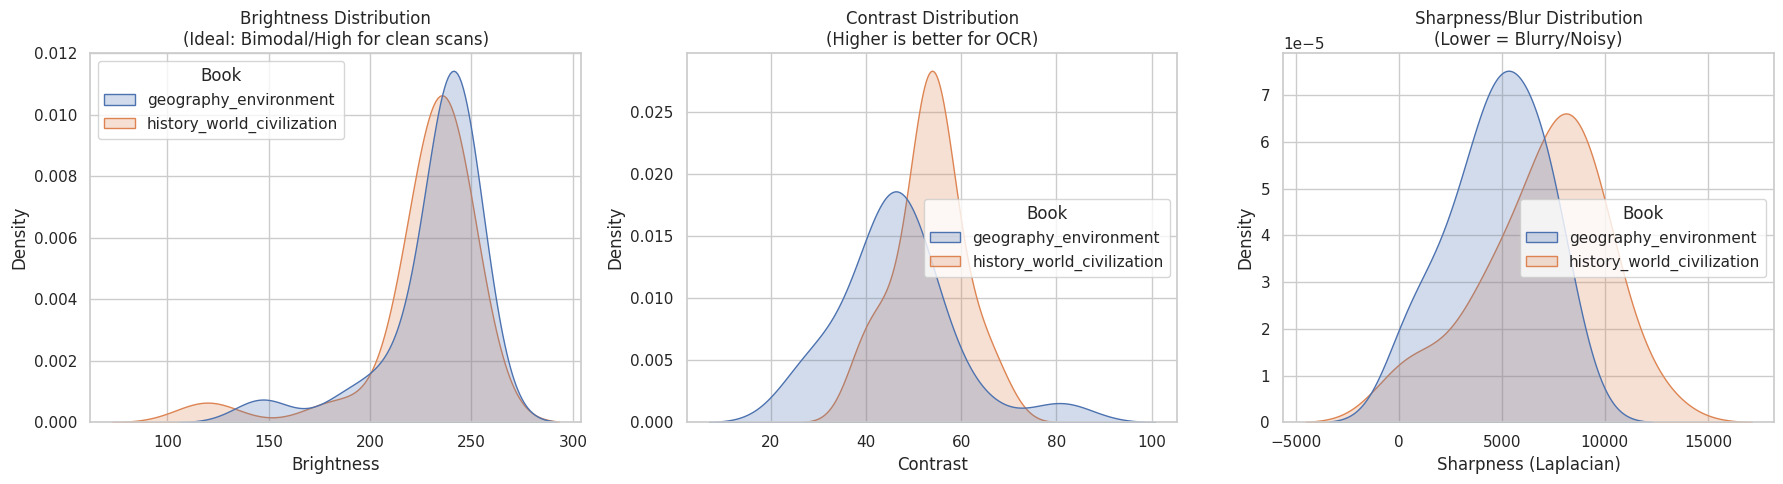

In [6]:
def analyze_scan_quality(pdf_paths, sample_size=20, dpi=150):
    quality_data = []
    
    for pdf_path in pdf_paths:
        doc = fitz.open(pdf_path)
        num_pages = len(doc)
        
        # Sample pages evenly across the book
        sample_pages = np.linspace(0, num_pages - 1, min(sample_size, num_pages), dtype=int)
        
        for page_num in tqdm(sample_pages, desc=f"Analyzing {pdf_path.stem[:15]}..."):
            # FIX: Cast np.int64 to standard Python int for PyMuPDF
            page = doc[int(page_num)] 
            
            pix = page.get_pixmap(matrix=fitz.Matrix(dpi/72, dpi/72))
            
            # Convert to OpenCV grayscale array
            img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
            if pix.n == 3:
                gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
            else:
                gray = img_array
                
            # Metrics
            brightness = np.mean(gray)
            contrast = np.std(gray)
            blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
            
            quality_data.append({
                "Book": pdf_path.stem,
                "Page": int(page_num) + 1,
                "Brightness": brightness,
                "Contrast": contrast,
                "Sharpness (Laplacian)": blur_score
            })
        doc.close()
        
    return pd.DataFrame(quality_data)

df_quality = analyze_scan_quality(pdf_files)

# Visualize Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.kdeplot(data=df_quality, x="Brightness", hue="Book", fill=True, ax=axes[0])
axes[0].set_title("Brightness Distribution\n(Ideal: Bimodal/High for clean scans)")

sns.kdeplot(data=df_quality, x="Contrast", hue="Book", fill=True, ax=axes[1])
axes[1].set_title("Contrast Distribution\n(Higher is better for OCR)")

sns.kdeplot(data=df_quality, x="Sharpness (Laplacian)", hue="Book", fill=True, ax=axes[2])
axes[2].set_title("Sharpness/Blur Distribution\n(Lower = Blurry/Noisy)")

plt.tight_layout()
plt.show()

## 3. Script and Font Variety
We will extract the embedded font dictionaries to see how many different fonts are used in the PDFs. We will also analyze the extracted text to determine the ratio of Bengali script versus Latin (English) script and digits.

In [8]:
def analyze_fonts_and_scripts(pdf_paths):
    font_data = []
    script_data = []
    
    for pdf_path in pdf_paths:
        doc = fitz.open(pdf_path)
        
        # 1. Font Variety
        fonts_used = set()
        bangla_chars = 0
        latin_chars = 0
        other_chars = 0
        
        for page_num in range(min(50, len(doc))): # Sample first 50 pages for speed
            page = doc[page_num]
            
            # Extract fonts
            for font in page.get_fonts():
                fonts_used.add(font[3]) # Font name is usually at index 3
                
            # Extract text for script analysis
            text = page.get_text("text")
            for char in text:
                if char.isspace():
                    continue
                cp = ord(char)
                if 0x0980 <= cp <= 0x09FF:
                    bangla_chars += 1
                elif char.isascii() and char.isalnum():
                    latin_chars += 1
                else:
                    other_chars += 1
                    
        total_chars = bangla_chars + latin_chars + other_chars
        if total_chars > 0:
            script_data.append({
                "Book": pdf_path.stem,
                "Bengali %": (bangla_chars / total_chars) * 100,
                "Latin/English %": (latin_chars / total_chars) * 100,
                "Punctuation/Other %": (other_chars / total_chars) * 100
            })
            
        font_data.append({
            "Book": pdf_path.stem,
            "Unique Fonts": len(fonts_used),
            "Font Names": ", ".join(list(fonts_used)[:5]) + "..." if fonts_used else "None"
        })
        doc.close()
        
    return pd.DataFrame(font_data), pd.DataFrame(script_data)

df_fonts, df_scripts = analyze_fonts_and_scripts(pdf_files)

print("--- Font Analysis ---")
display(df_fonts)

print("\n--- Script Analysis ---")
if df_scripts.empty:
    print("WARNING: df_scripts is empty. This means PyMuPDF could not find any native text in the first 50 pages.")
    print("These PDFs are likely raw scanned images with no embedded OCR layer.")
else:
    display(df_scripts)
    # Plot Script Distribution
    df_scripts.set_index('Book').plot(kind='bar', stacked=True, figsize=(10, 6), colormap="Set2")
    plt.title("Character Script Distribution (Sampled from Native Text Layer)")
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
    plt.tight_layout()
    plt.show()

--- Font Analysis ---


,Book,Unique Fonts,Font Names
0,geography_environment,0,None
1,history_world_civilization,0,None



--- Script Analysis ---
These PDFs are likely raw scanned images with no embedded OCR layer.
